In [10]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.messages import RemoveMessage

In [11]:
load_dotenv()

True

In [12]:
model = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

In [13]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [14]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [15]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", "__end__")

In [16]:
graph = builder.compile(checkpointer=InMemorySaver())

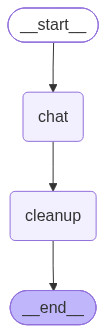

In [17]:
graph

In [18]:
config = {"configurable": {"thread_id": "t1"}}

In [19]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Nitish"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='f4272102-9262-40e3-9b95-7ddd1e3801ab'),
  AIMessage(content=[{'type': 'text', 'text': '**LangChain** is an open-source development framework designed to make it easier to build applications using Large Language Models (LLMs) like GPT-4, Claude, or open-source models like Llama. \n\nThink of LangChain as the **"glue" or toolkit** that connects powerful LLMs to the rest of the digital world (databases, APIs, files, and other software).\n\nHere is a breakdown of why LangChain exists and what it does:\n\n---\n\n### 1. The Problem LangChain Solves\nOut of the box, an LLM is like a brilliant brain in a jar. It knows a lot of general information, but:\n* It doesn\'t know private company data.\n* It can\'t browse the live internet (unless built-in).\n* It can\'t take actions (like sending an email or querying a database).\n* It only handles one prompt and response at a time; building a multi

In [21]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 8
